# CAP4453 — Assignment 4: Vision Transformer (ViT) on CIFAR‑10 — Depth Comparison (DEPTH=2 vs DEPTH=4)

In this assignment you will implement a **minimal Vision Transformer (ViT)** with a configurable encoder **depth** and train it on **CIFAR‑10** (32×32 images).

**What you will do :**
- Implement the ViT components in the cells marked **STUDENT TODO** (PatchEmbed, TransformerEncoderBlock, ViT).
- Run **two** experiments:
  - **DEPTH = 2**
  - **DEPTH = 4**
- select the **best checkpoint by validation accuracy**, then evaluate **once** on the test set.

**What you will report:**
- Best **validation accuracy** and final **test accuracy** for **DEPTH=2** and **DEPTH=4**
- Training curves: **train/val loss** and **train/val accuracy**
- A few **misclassified test examples** for each depth (image + predicted label + true label)



## 1) Setup & Environment

In [1]:
# Minimal imports
import os, random, math, time
from typing import Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2) CIFAR‑10 Data & Transforms (32×32)

**Fixed setup (no tuning):**
- We use native **32×32** CIFAR‑10 images.
- We use a **standard CIFAR‑10 augmentation** for training (crop + flip) and deterministic transforms for validation/test.
- A **fixed train/val split** is created with a seed for reproducibility.

You do **not** need to change transforms or split settings for this assignment.


In [2]:
# ---- CONFIG (fixed; no tuning) ----
DATA_DIR    = './data'
NUM_WORKERS = 2
IMAGE_SIZE  = 32
VAL_RATIO   = 0.1

# CPU-friendly defaults (auto-adjust)
if torch.cuda.is_available():
    BATCH_SIZE = 128
else:
    BATCH_SIZE = 64

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# ---- Transforms (fixed) ----
train_tfms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

val_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ---- Datasets (note: val uses deterministic transforms) ----
train_ds_full = datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_tfms)
val_ds_full   = datasets.CIFAR10(root=DATA_DIR, train=True,  download=False, transform=val_test_tfms)
test_ds       = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_test_tfms)

# ---- Fixed train/val split (reproducible) ----
n_total = len(train_ds_full)
n_val   = int(n_total * VAL_RATIO)
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g).tolist()
val_idx   = perm[:n_val]
train_idx = perm[n_val:]

train_ds = torch.utils.data.Subset(train_ds_full, train_idx)
val_ds   = torch.utils.data.Subset(val_ds_full,   val_idx)

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Batch size: {BATCH_SIZE}')


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s] 


Train: 45000 | Val: 5000 | Test: 10000 | Batch size: 128


## 3) Vision Transformer (ViT) Components — Configurable Depth

Implement a minimal ViT with a configurable encoder **depth** (number of Transformer blocks).

Architecture:
1. **Patch embedding**: `Conv2d(in_ch, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)` → flatten into tokens.
2. **[CLS] token + positional embeddings**: prepend a learnable class token; add learnable positional encodings.
3. **Transformer encoder blocks (× depth)**: LayerNorm → Multi‑Head Self‑Attention → residual → LayerNorm → MLP → residual.
4. **Classifier head**: use the [CLS] token → linear layer to 10 classes.

Only the **model components** are student‑implemented in this notebook.


In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, in_ch: int, embed_dim: int, patch_size: int):
        super().__init__()
        # STUDENT TODO: Conv2d with kernel_size=stride=patch_size; then flatten to (B, N, D)
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x

In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        # STUDENT TODO: ln1, mha, ln2, mlp (Linear->GELU->Dropout->Linear->Dropout)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # STUDENT TODO: x + attn(residual), x + mlp(residual)
        residual = x
        x_norm = self.ln1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = residual + self.drop(attn_out)

        residual = x
        x_norm = self.ln2(x)
        x = residual + self.mlp(x_norm) 

        return x



In [10]:
class ViT(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_chans: int,
                 num_classes: int, embed_dim: int, num_heads: int, mlp_ratio: float,
                 depth: int, dropout: float = 0.0):
        super().__init__()
        assert image_size % patch_size == 0, 'image_size must be divisible by patch_size'
        self.num_patches = (image_size // patch_size) * (image_size // patch_size)

        # STUDENT TODO: create patch embedder
        self.patch_embed = PatchEmbed(in_chans, embed_dim, patch_size)

        # STUDENT TODO: class token, pos_embed, dropout
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # STUDENT TODO: stack `depth` encoder blocks (use nn.ModuleList or nn.Sequential)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        # STUDENT TODO: final norm + classifier head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # STUDENT TODO: patchify -> [CLS] prepend -> add pos -> encoders (loop over blocks) -> norm -> take CLS -> head
        x = self.patch_embed(x)

        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]
        logits = self.head(cls_out)
        return logits

## 4) ViT Hyper‑Parameters (fixed; depth varies)

To reduce workload and keep runtime reasonable, this assignment uses **fixed** ViT settings.

You will run **two depths only**:
- **DEPTH = 2**
- **DEPTH = 4**

Do **not** change other hyper‑parameters unless instructed by the course staff.


In [12]:
# Fixed ViT hyper-parameters (no tuning)
PATCH_SIZE  = 4
EMBED_DIM   = 128
NUM_HEADS   = 4
MLP_RATIO   = 4.0
DROPOUT     = 0.1
NUM_CLASSES = 10

def make_vit(depth: int) -> nn.Module:
    """Factory for ViT models at a given depth."""
    return ViT(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=3,
        num_classes=NUM_CLASSES,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        depth=depth,
        dropout=DROPOUT,
    )


In [11]:
# Quick sanity check (no training)
_m = make_vit(depth=2).to(device)
_x = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
_logits = _m(_x)
print('Sanity check logits shape:', tuple(_logits.shape))
del _m, _x, _logits

Sanity check logits shape: (4, 10)


## 5) Optimiser / Loss (fixed; no tuning)

We use a standard configuration for ViT training on CIFAR‑10:
- Optimiser: **AdamW**
- Loss: **Cross‑Entropy**

These settings are fixed in the notebook to avoid hyper‑parameter tuning.


In [13]:
# Training configuration (fixed; no tuning)
if torch.cuda.is_available():
    EPOCHS = 20
else:
    EPOCHS = 10

BASE_LR      = 3e-4
WEIGHT_DECAY = 0.05
BETAS        = (0.9, 0.999)
GRAD_CLIP    = 1.0  # keep training stable; set to None to disable

criterion = nn.CrossEntropyLoss()

def make_optimizer(model: nn.Module):
    return torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY, betas=BETAS)


## 6) Training & Evaluation (provided)

The training / evaluation utilities below are provided.  
Once you finish the ViT implementation, you should be able to run the two experiments (DEPTH=2 and DEPTH=4) end‑to‑end.


In [14]:
def _accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item() * 100.0

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=None) -> Tuple[float, float]:
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, (total_correct / total_n) * 100.0

@torch.no_grad()
def evaluate(model, loader, criterion, device) -> Tuple[float, float]:
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, (total_correct / total_n) * 100.0

def plot_curves(history: dict, title: str):
    epochs = np.arange(1, len(history['train_loss']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_loss'], label='train loss')
    plt.plot(epochs, history['val_loss'], label='val loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.title(title + ' — Loss'); plt.legend(); plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='train acc')
    plt.plot(epochs, history['val_acc'], label='val acc')
    plt.xlabel('epoch'); plt.ylabel('accuracy (%)'); plt.title(title + ' — Accuracy'); plt.legend(); plt.show()

def run_experiment(depth: int, tag: str):
    """Train once for a given depth, pick best checkpoint by val accuracy, then test once."""
    model = make_vit(depth).to(device)
    optimizer = make_optimizer(model)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state = None

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, grad_clip=GRAD_CLIP)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            # store on CPU to avoid GPU memory bloat
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"[{tag}] epoch {epoch:02d}/{EPOCHS} | train {tr_loss:.4f}, {tr_acc:.2f}% | val {va_loss:.4f}, {va_acc:.2f}%")

    elapsed = time.time() - t0
    print(f"[{tag}] training done in {elapsed/60:.1f} min | best val acc: {best_val_acc:.2f}%")

    # Save best checkpoint
    ckpt_path = f"best_vit_{tag}.pt"
    torch.save({'depth': depth, 'state_dict': best_state}, ckpt_path)
    print(f"[{tag}] saved best checkpoint: {ckpt_path}")

    # Load best checkpoint and evaluate once on val + test
    model.load_state_dict(best_state)
    best_val_loss, best_val_acc2 = evaluate(model, val_loader, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    results = {
        'tag': tag,
        'depth': depth,
        'best_val_acc': best_val_acc2,
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'ckpt_path': ckpt_path,
        'history': history,
    }
    return model, results


## 7) Experiment A — DEPTH = 2

Run a single training run with **DEPTH=2**.  
The notebook will automatically keep the **best epoch by validation accuracy** and then evaluate once on the test set.


[depth2] epoch 01/20 | train 1.8014, 32.93% | val 1.6033, 42.16%
[depth2] epoch 02/20 | train 1.5397, 43.98% | val 1.3765, 50.98%
[depth2] epoch 03/20 | train 1.4113, 48.61% | val 1.3302, 52.34%
[depth2] epoch 04/20 | train 1.3428, 51.37% | val 1.2073, 57.12%
[depth2] epoch 05/20 | train 1.2843, 53.29% | val 1.1822, 58.08%
[depth2] epoch 06/20 | train 1.2412, 55.08% | val 1.1626, 58.74%
[depth2] epoch 07/20 | train 1.2042, 56.43% | val 1.0950, 61.06%
[depth2] epoch 08/20 | train 1.1701, 57.82% | val 1.0513, 63.18%
[depth2] epoch 09/20 | train 1.1319, 59.21% | val 1.0771, 62.16%
[depth2] epoch 10/20 | train 1.1085, 59.96% | val 1.0398, 63.22%
[depth2] epoch 11/20 | train 1.0881, 60.52% | val 0.9899, 65.22%
[depth2] epoch 12/20 | train 1.0620, 61.70% | val 1.0044, 64.64%
[depth2] epoch 13/20 | train 1.0413, 62.27% | val 0.9646, 65.62%
[depth2] epoch 14/20 | train 1.0274, 62.98% | val 0.9778, 65.38%
[depth2] epoch 15/20 | train 1.0047, 63.88% | val 0.9311, 66.80%
[depth2] epoch 16/20 | tr

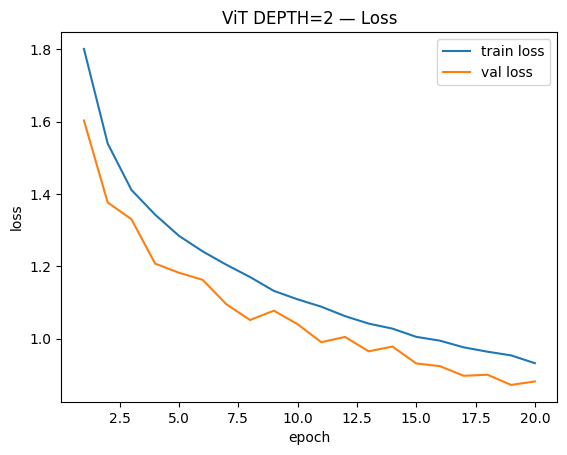

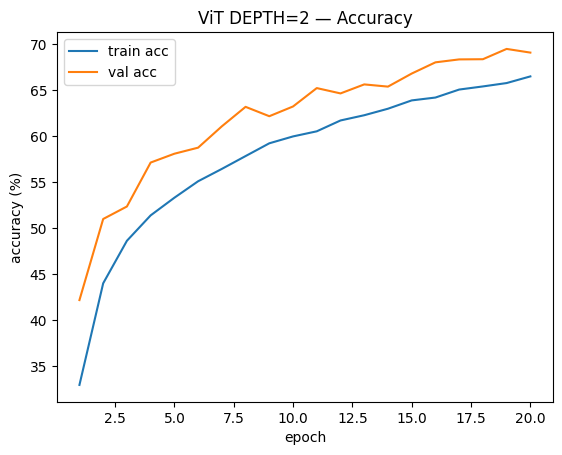

DEPTH=2 results:
  best val acc: 69.48%
  test acc:     68.33%


In [15]:
# Experiment A: DEPTH=2
model_d2, results_d2 = run_experiment(depth=2, tag='depth2')

plot_curves(results_d2['history'], title='ViT DEPTH=2')

print('DEPTH=2 results:')
print(f"  best val acc: {results_d2['best_val_acc']:.2f}%")
print(f"  test acc:     {results_d2['test_acc']:.2f}%")


## 8) Experiment B — DEPTH = 4

Run a single training run with **DEPTH=4** using the **same fixed settings**.  
Again, select the best checkpoint by validation accuracy and evaluate once on the test set.


[depth4] epoch 01/20 | train 1.7854, 33.08% | val 1.6980, 39.96%
[depth4] epoch 02/20 | train 1.5076, 44.96% | val 1.4127, 49.94%
[depth4] epoch 03/20 | train 1.3776, 49.65% | val 1.2797, 54.70%
[depth4] epoch 04/20 | train 1.2890, 53.10% | val 1.1862, 57.54%
[depth4] epoch 05/20 | train 1.2210, 55.87% | val 1.1079, 60.18%
[depth4] epoch 06/20 | train 1.1708, 57.64% | val 1.0674, 61.68%
[depth4] epoch 07/20 | train 1.1289, 59.49% | val 1.0313, 63.16%
[depth4] epoch 08/20 | train 1.0953, 60.56% | val 0.9910, 65.06%
[depth4] epoch 09/20 | train 1.0632, 61.69% | val 1.0058, 64.00%
[depth4] epoch 10/20 | train 1.0302, 62.92% | val 0.9482, 66.56%
[depth4] epoch 11/20 | train 0.9972, 64.03% | val 0.9356, 67.24%
[depth4] epoch 12/20 | train 0.9710, 65.26% | val 0.8922, 67.84%
[depth4] epoch 13/20 | train 0.9435, 66.09% | val 0.8872, 68.68%
[depth4] epoch 14/20 | train 0.9212, 67.06% | val 0.8552, 69.46%
[depth4] epoch 15/20 | train 0.8972, 68.07% | val 0.8362, 70.86%
[depth4] epoch 16/20 | tr

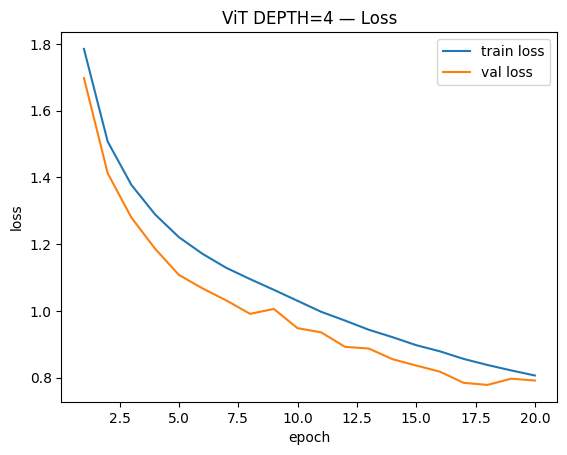

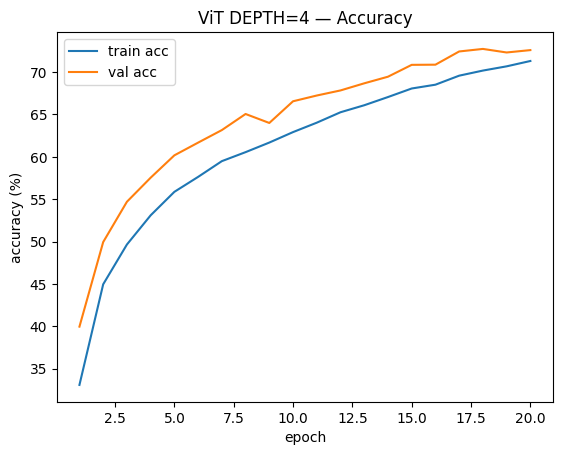

DEPTH=4 results:
  best val acc: 72.74%
  test acc:     71.47%


In [16]:
# Experiment B: DEPTH=4
model_d4, results_d4 = run_experiment(depth=4, tag='depth4')

plot_curves(results_d4['history'], title='ViT DEPTH=4')

print('DEPTH=4 results:')
print(f"  best val acc: {results_d4['best_val_acc']:.2f}%")
print(f"  test acc:     {results_d4['test_acc']:.2f}%")


## 9) Comparison Summary (what to include in your report)

In your report, include:
- A short table with **best validation accuracy** and **test accuracy** for **DEPTH=2** and **DEPTH=4**
- The learning curves you plotted above (loss + accuracy)
- A few misclassified test examples for each depth (next section)
- 3–6 sentences comparing DEPTH=2 vs DEPTH=4 (accuracy, convergence, any overfitting signs)


In [17]:
# Summary table (copy into your report)
print("\n=== Summary ===")
print(f"DEPTH=2 | best val acc: {results_d2['best_val_acc']:.2f}% | test acc: {results_d2['test_acc']:.2f}%")
print(f"DEPTH=4 | best val acc: {results_d4['best_val_acc']:.2f}% | test acc: {results_d4['test_acc']:.2f}%")



=== Summary ===
DEPTH=2 | best val acc: 69.48% | test acc: 68.33%
DEPTH=4 | best val acc: 72.74% | test acc: 71.47%


## 10) Misclassified Test Examples 

Show a few test images that the model classified incorrectly for **each depth**.
Include the **true label** and the **predicted label**.


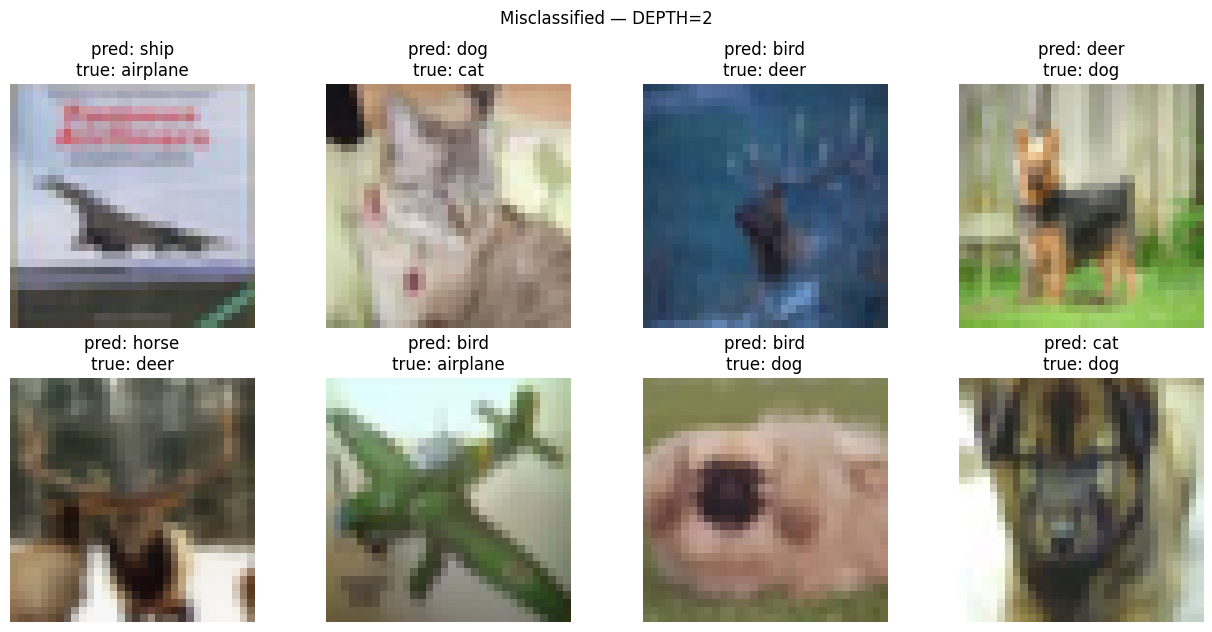

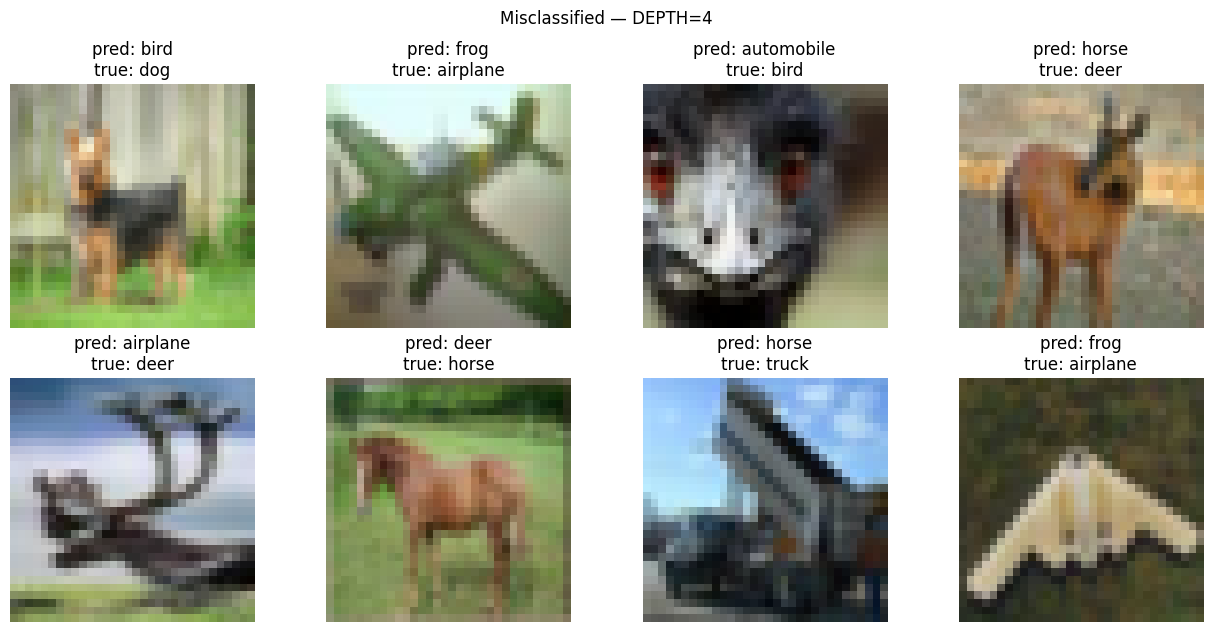

In [18]:
CLASSES = test_ds.classes
_mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
_std  = torch.tensor(CIFAR_STD).view(3, 1, 1)

def _unnormalize(img_chw: torch.Tensor) -> torch.Tensor:
    return (img_chw * _std) + _mean

@torch.no_grad()
def show_misclassified(model: nn.Module, loader: DataLoader, max_images: int = 8, title: str = ''):
    model.eval()
    imgs, preds, trues = [], [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        p = logits.argmax(dim=1)
        wrong = (p != y)

        if wrong.any():
            idxs = torch.where(wrong)[0].tolist()
            for i in idxs:
                imgs.append(x[i].cpu())
                preds.append(int(p[i].cpu()))
                trues.append(int(y[i].cpu()))
                if len(imgs) >= max_images:
                    break
        if len(imgs) >= max_images:
            break

    if len(imgs) == 0:
        print('No misclassifications found (unlikely).')
        return

    cols = 4
    rows = math.ceil(len(imgs) / cols)
    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for k, img in enumerate(imgs):
        img = _unnormalize(img).clamp(0, 1)
        img_hwc = img.permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, k + 1)
        plt.imshow(img_hwc)
        plt.title(f"pred: {CLASSES[preds[k]]}\ntrue: {CLASSES[trues[k]]}")
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_misclassified(model_d2, test_loader, max_images=8, title='Misclassified — DEPTH=2')
show_misclassified(model_d4, test_loader, max_images=8, title='Misclassified — DEPTH=4')
